In [1]:
#Cell 0 - Check Python executable path
import sys
sys.executable

'c:\\python314\\python.exe'

In [2]:
#Cell 1 — Install dependencies
!pip install requests beautifulsoup4 pandas ipywidgets matplotlib pillow

Defaulting to user installation because normal site-packages is not writeable


In [32]:
#Cell 2 — Imports + base URL
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display

#BASE_URL = "https://west.englandhockey.co.uk/competitions/2025-2026-4572903-adult-west-open---mens-group-4574807-west-open---mens-division-2-central/fixtures?match-day="
BASE_URL = "https://west.englandhockey.co.uk/competitions/2025-2026-4572903-adult-west-open---mens-group-4574203-west-open---mens-division-1-south/fixtures?match-day="

HIGHLIGHT_TEAM = "Isca M4"

In [33]:
#Cell 3 — Generate match‑day dates
start = datetime(2025, 9, 27)
end = datetime(2026, 4, 18)

all_dates = []
d = start
while d <= end:
    if d.weekday() == 5:  # Saturday
        all_dates.append(d)
    d += timedelta(days=1)

no_matches = {
    datetime(2025, 11, 1),
    datetime(2025, 12, 13),
    datetime(2025, 12, 20),
    datetime(2025, 12, 27),
    datetime(2026, 1, 3),
    datetime(2026, 1, 10)
}

match_days = [d for d in all_dates if d not in no_matches]
match_days

[datetime.datetime(2025, 9, 27, 0, 0),
 datetime.datetime(2025, 10, 4, 0, 0),
 datetime.datetime(2025, 10, 11, 0, 0),
 datetime.datetime(2025, 10, 18, 0, 0),
 datetime.datetime(2025, 10, 25, 0, 0),
 datetime.datetime(2025, 11, 8, 0, 0),
 datetime.datetime(2025, 11, 15, 0, 0),
 datetime.datetime(2025, 11, 22, 0, 0),
 datetime.datetime(2025, 11, 29, 0, 0),
 datetime.datetime(2025, 12, 6, 0, 0),
 datetime.datetime(2026, 1, 17, 0, 0),
 datetime.datetime(2026, 1, 24, 0, 0),
 datetime.datetime(2026, 1, 31, 0, 0),
 datetime.datetime(2026, 2, 7, 0, 0),
 datetime.datetime(2026, 2, 14, 0, 0),
 datetime.datetime(2026, 2, 21, 0, 0),
 datetime.datetime(2026, 2, 28, 0, 0),
 datetime.datetime(2026, 3, 7, 0, 0),
 datetime.datetime(2026, 3, 14, 0, 0),
 datetime.datetime(2026, 3, 21, 0, 0),
 datetime.datetime(2026, 3, 28, 0, 0),
 datetime.datetime(2026, 4, 4, 0, 0),
 datetime.datetime(2026, 4, 11, 0, 0),
 datetime.datetime(2026, 4, 18, 0, 0)]

In [39]:
#r = requests.get("https://eh-dw-prod.azurewebsites.net/api/competitions/1d2fc097-e0d5-4f2a-96ba-ecb030655ebb/matchdays/2025-09-27")
r = requests.get("https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-09-27")
print(r.status_code)
print(r.text[:200])

401



In [40]:
#Cell 4 — Scrape match results
API_BASE_M4 = "https://eh-dw-prod.azurewebsites.net/api/competitions/1d2fc097-e0d5-4f2a-96ba-ecb030655ebb/matchdays/"

API_BASE = "https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/"

import os

# The England Hockey data API needs a key. It is read from the environment so
# it never lands in this repo:  set EH_API_KEY before running.
headers = {
    "x-functions-key": os.environ["EH_API_KEY"]
}

results = []

for day in match_days:
    url = API_BASE + day.strftime("%Y-%m-%d")
    print("Fetching:", url)

    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print("  Status:", r.status_code, "— skipping")
        continue

    if not r.text.strip():
        print("  Empty response — skipping")
        continue

    try:
        data = r.json()
    except ValueError:
        print("  Invalid JSON — skipping")
        continue

    print(f"  Found {len(data)} fixtures")

    for fixture in data:
        if not fixture.get("isResult", False):
            continue

        results.append({
            "date": pd.to_datetime(fixture["fixtureDate"]).date(),
            "home": fixture["homeTeam"]["teamName"],
            "away": fixture["awayTeam"]["teamName"],
            "home_goals": fixture["homeTeamScoreAsInt"],
            "away_goals": fixture["awayTeamScoreAsInt"]
        })

print("Total matches scraped:", len(results))

df = pd.DataFrame(results)
df.head()

Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-09-27
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-10-04
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-10-11
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-10-18
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-10-25
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-11-08
  Status: 404 — skipping
Fetching: https://eh-dw-prod.azurewebsites.net/api/competitions/8c9b4c9d-2c3d-4c1a-9f2f-1e7c1c1b4b8e/matchdays/2025-11

""


In [20]:
#Cell 4.5 - 

# results_raw = your scraped match results from Cell 4

import pandas as pd

# Convert scraped list → DataFrame
results_scores = pd.DataFrame(results)

rows_per_team = []

for _, r in results_scores.iterrows():
    # Home team row
    rows_per_team.append({
        "date": r["date"],
        "team": r["home"],
        "opponent": r["away"],
        "gf": r["home_goals"],
        "ga": r["away_goals"],
        "outcome": (
            "W" if r["home_goals"] > r["away_goals"]
            else "D" if r["home_goals"] == r["away_goals"]
            else "L"
        )
    })

    # Away team row
    rows_per_team.append({
        "date": r["date"],
        "team": r["away"],
        "opponent": r["home"],
        "gf": r["away_goals"],
        "ga": r["home_goals"],
        "outcome": (
            "W" if r["away_goals"] > r["home_goals"]
            else "D" if r["away_goals"] == r["home_goals"]
            else "L"
        )
    })

results_per_team = pd.DataFrame(rows_per_team).sort_values(["team", "date"])
results_per_team

,date,team,opponent,gf,ga,outcome
8,2025-09-27,Bridgwater M1,Mid Somerset M1,4,1,W
23,2025-10-04,Bridgwater M1,Chard M1,6,2,W
26,2025-10-11,Bridgwater M1,Bristol Firebrands M2,3,0,W
39,2025-10-18,Bridgwater M1,Team Bath Buccaneers M5,1,1,D
52,2025-10-25,Bridgwater M1,Clifton Robinsons M5,2,1,W
...,...,...,...,...,...,...
204,2026-03-14,Yeovil & Sherborne M1,Taunton Vale M2,2,6,L
223,2026-03-21,Yeovil & Sherborne M1,Chard M1,1,4,L
230,2026-03-28,Yeovil & Sherborne M1,Bridgwater M1,2,2,D
245,2026-04-11,Yeovil & Sherborne M1,Bristol Firebrands M2,2,10,L


In [21]:
#Cell 5 — Compute points per match
def match_points(row):
    if row.home_goals > row.away_goals:
        return 3, 0
    elif row.home_goals < row.away_goals:
        return 0, 3
    else:
        return 1, 1

df["home_points"], df["away_points"] = zip(*df.apply(match_points, axis=1))
df.head()

,date,home,away,home_goals,away_goals,home_points,away_points
0,2025-09-27,Tiverton White Eagles M1,Bristol Firebrands M2,1,5,0,3
1,2025-09-27,Taunton Vale M2,Chard M1,4,3,3,0
2,2025-09-27,Culm Valley Hornets M1,Clifton Robinsons M5,2,1,3,0
3,2025-09-27,Isca M4,Yeovil & Sherborne M1,1,2,0,3
4,2025-09-27,Bridgwater M1,Mid Somerset M1,4,1,3,0


In [22]:
#Cell 6 — Build cumulative league table
teams = sorted(set(df["home"]).union(df["away"]))
weeks = sorted(df["date"].unique())

rows = []

for week in weeks:
    week_df = df[df["date"] <= week]

    for team in teams:
        played = len(week_df[(week_df.home == team) | (week_df.away == team)])
        won = len(week_df[(week_df.home == team) & (week_df.home_goals > week_df.away_goals)]) + \
              len(week_df[(week_df.away == team) & (week_df.away_goals > week_df.home_goals)])
        drawn = len(week_df[(week_df.home == team) & (week_df.home_goals == week_df.away_goals)]) + \
                len(week_df[(week_df.away == team) & (week_df.home_goals == week_df.away_goals)])
        lost = played - won - drawn

        gf = week_df[week_df.home == team].home_goals.sum() + \
             week_df[week_df.away == team].away_goals.sum()
        ga = week_df[week_df.home == team].away_goals.sum() + \
             week_df[week_df.away == team].home_goals.sum()

        points = (
            week_df[week_df.home == team].home_points.sum() +
            week_df[week_df.away == team].away_points.sum()
        )

        rows.append({
            "week": week,
            "date": week.strftime("%Y-%m-%d"),
            "team": team,
            "played": played,
            "won": won,
            "drawn": drawn,
            "lost": lost,
            "gf": gf,
            "ga": ga,
            "gd": gf - ga,
            "points": points
        })

table = pd.DataFrame(rows)
table = table.sort_values(["week", "points", "gd", "gf"], ascending=[True, False, False, False])
# Assign correct league positions per week
table["position"] = (
    table.groupby("week")
         .cumcount() + 1
)
table.head()

,week,date,team,played,won,drawn,lost,gf,ga,gd,points,position
1,2025-09-27,2025-09-27,Bristol Firebrands M2,1,1,0,0,5,1,4,3,1
0,2025-09-27,2025-09-27,Bridgwater M1,1,1,0,0,4,1,3,3,2
7,2025-09-27,2025-09-27,Sidmouth & Ottery M1,1,1,0,0,3,0,3,3,3
8,2025-09-27,2025-09-27,Taunton Vale M2,1,1,0,0,4,3,1,3,4
4,2025-09-27,2025-09-27,Culm Valley Hornets M1,1,1,0,0,2,1,1,3,5


In [23]:
table.head()


,week,date,team,played,won,drawn,lost,gf,ga,gd,points,position
1,2025-09-27,2025-09-27,Bristol Firebrands M2,1,1,0,0,5,1,4,3,1
0,2025-09-27,2025-09-27,Bridgwater M1,1,1,0,0,4,1,3,3,2
7,2025-09-27,2025-09-27,Sidmouth & Ottery M1,1,1,0,0,3,0,3,3,3
8,2025-09-27,2025-09-27,Taunton Vale M2,1,1,0,0,4,3,1,3,4
4,2025-09-27,2025-09-27,Culm Valley Hornets M1,1,1,0,0,2,1,1,3,5


In [24]:
#Cell 7 — Save CSV
table.to_csv("hockey_league_cumulative.csv", index=False)
print("Done! File saved as hockey_league_cumulative.csv")

Done! File saved as hockey_league_cumulative.csv


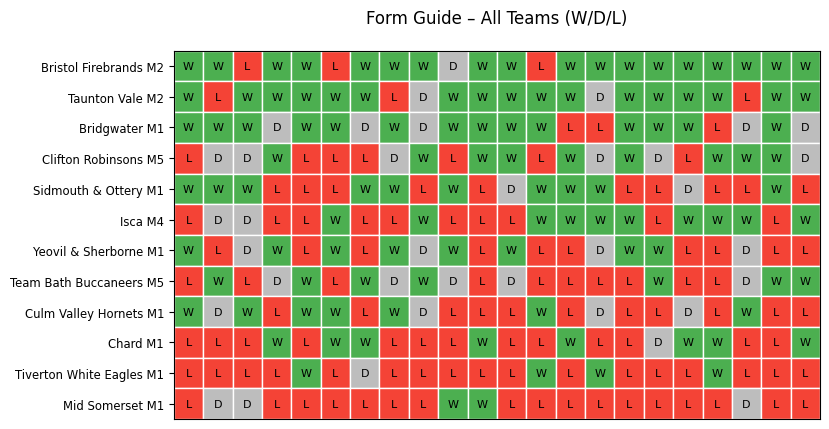

In [25]:
#Cell 7.5 - BBC style heat map of results
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

latest_positions = (
    table.sort_values("date")
         .groupby("team")
         .tail(1)[["team", "position"]]
         .set_index("team")
)

teams_sorted = latest_positions.sort_values("position").index.tolist()

# Use your per-team results table
df_results = results_per_team.copy()
df_results = df_results.sort_values(["team", "date"])

teams = df_results["team"].unique()

# Build a dict: team → list of outcomes in order
team_form = {
    team: df_results[df_results["team"] == team]["outcome"].tolist()
    for team in teams_sorted
}

# Colour map for outcomes
colors = {"W": "#4CAF50", "D": "#BDBDBD", "L": "#F44336"}

# Determine max number of matches any team has played
max_games = max(len(v) for v in team_form.values())

fig, ax = plt.subplots(figsize=(max_games * 0.2 + 4, len(teams_sorted) * 0.2 + 2))

# Draw the grid
for row_idx, team in enumerate(teams_sorted):
    outcomes = team_form[team]
    for col_idx, outcome in enumerate(outcomes):
        rect = patches.Rectangle(
            (col_idx, row_idx),
            1, 1,
            facecolor=colors[outcome],
            edgecolor="white"
        )
        ax.add_patch(rect)
        ax.text(
            col_idx + 0.5,
            row_idx + 0.5,
            outcome,
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Formatting
ax.set_xlim(0, max_games)
ax.set_ylim(0, len(teams_sorted))
ax.set_yticks([i + 0.5 for i in range(len(teams))])
ax.set_yticklabels(teams_sorted, fontsize="small")
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title("Form Guide – All Teams (W/D/L)", fontsize=12, pad=20)

plt.tight_layout()
plt.show()

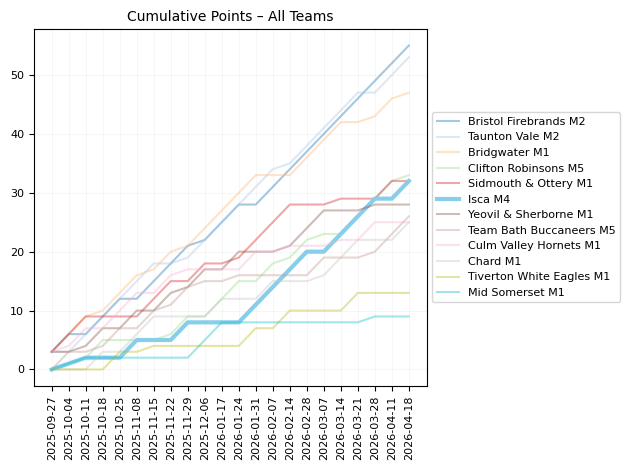

In [ ]:
#Cell 8 — Plot cumulative points for all teams

cmap = plt.colormaps.get_cmap("tab20")
team_colors = {team: cmap(i / len(teams_sorted)) for i, team in enumerate(teams_sorted)}
team_colors[HIGHLIGHT_TEAM] = "skyblue"

for _, team in enumerate(teams_sorted):
    subset = table[table.team == team]

    if team == HIGHLIGHT_TEAM:
        plt.plot(
            subset.date,
            subset.points,
            color=team_colors[team],
            linewidth=3,
            label=team
        )
    else:
        plt.plot(
            subset.date,
            subset.points,
            color=team_colors[team],
            alpha=0.4,
            label=team
        )

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title("Cumulative Points – All Teams", fontsize="medium")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, color="grey", alpha=0.1, linewidth=0.5)
plt.tight_layout()
plt.show()

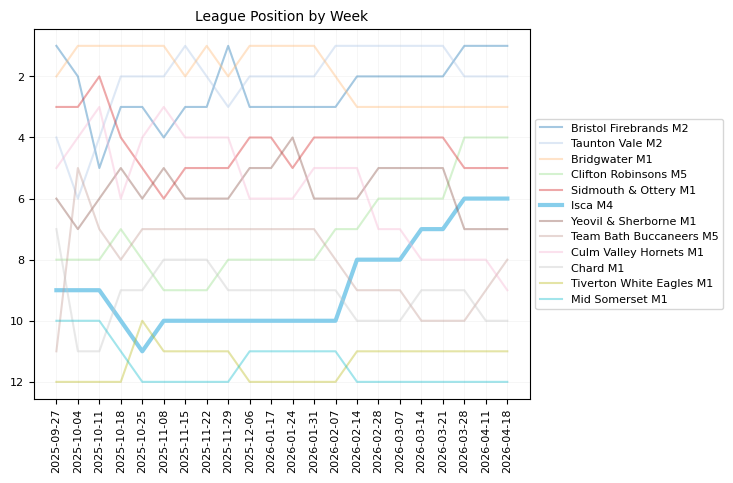

In [ ]:
#Cell 9 — Plot league position per week
#plt.figure(figsize=(14, 8))

#HIGHLIGHT_TEAM = "Isca M4"

cmap = plt.colormaps.get_cmap("tab20")
team_colors = {team: cmap(i / len(teams_sorted)) for i, team in enumerate(teams_sorted)}
team_colors[HIGHLIGHT_TEAM] = "skyblue"

for _, team in enumerate(teams_sorted):
    subset = table[table.team == team]

    if team == HIGHLIGHT_TEAM:
        plt.plot(
            subset.date,
            subset.position,
            color=team_colors[team],
            linewidth=3,
            label=team
        )
    else:
        plt.plot(
            subset.date,
            subset.position,
            color=team_colors[team],
            alpha=0.4,
            label=team
        )

plt.gca().invert_yaxis()  # 1st place at top
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title("League Position by Week", fontsize="medium")
plt.grid(True, color="grey", alpha=0.1, linewidth=0.5)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

Error in callback <function _draw_all_if_interactive at 0x000001AA0C33B270> (for post_execute), with arguments args (),kwargs {}:


TypeError: unsupported operand type(s) for -: 'str' and 'str'

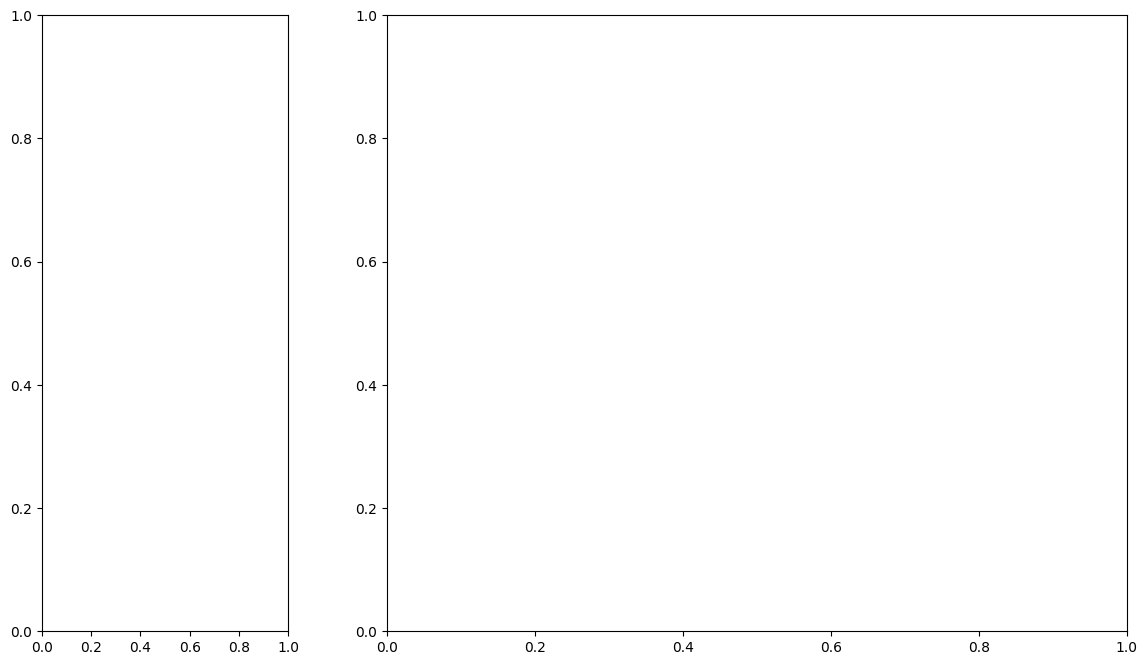

In [ ]:
#Cell 10 — Animated plot of league progression
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import gridspec
import numpy as np

weeks = sorted(table["week"].unique())
teams = sorted(table["team"].unique())

#HIGHLIGHT_TEAM = "Isca M4"

cmap = plt.colormaps.get_cmap("tab20")
team_colors = {team: cmap(i / len(teams)) for i, team in enumerate(teams)}
team_colors[HIGHLIGHT_TEAM] = "skyblue"

frames_per_step = 10
total_frames = (len(weeks) - 1) * frames_per_step + 1

def frame_to_week_index(f):
    return f // frames_per_step

def frame_alpha_within_step(f):
    return (f % frames_per_step) / max(frames_per_step - 1, 1)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])
ax_left = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1])

def init():
    ax_left.clear()
    ax_right.clear()

def update(frame):
    ax_left.clear()
    ax_right.clear()

    week_idx = frame_to_week_index(frame)
    alpha = frame_alpha_within_step(frame)

    if week_idx >= len(weeks) - 1:
        week_idx = len(weeks) - 1
        alpha = 1.0

    week_current = weeks[week_idx]
    week_next = weeks[min(week_idx + 1, len(weeks) - 1)]

    # RIGHT: cumulative points (smooth interpolation)
    for team in teams:
        team_data = table[table.team == team].sort_values("week")

        # Historical weeks up to current week
        past = team_data[team_data.week <= week_current].copy()

        # Interpolate between week_current and week_next
        if week_next != week_current:
            next_row = team_data[team_data.week == week_next]
            if not next_row.empty:
                last_points = past.points.iloc[-1] if not past.empty else 0
                target_points = next_row.points.iloc[0]

                # Smooth interpolation
                interp_points = last_points + (target_points - last_points) * alpha
                date0 = past.date.iloc[-1]
                date1 = next_row.date.iloc[0]
                interp_date = date0 + (date1 - date0) * alpha

                past = pd.concat(
                    [past,
                    pd.DataFrame([{"date": interp_date, "points": interp_points}])],
                    ignore_index=True
                )

        if not past.empty:
            lw = 2.5 if team == HIGHLIGHT_TEAM else 1.2
            z = 3 if team == HIGHLIGHT_TEAM else 1
            ax_right.plot(
                past.date,
                past.points,
                color=team_colors[team],
                linewidth=lw,
                alpha=1.0,
                zorder=z,
            )

    ax_right.set_title(f"Cumulative Points (up to {week_next.strftime('%Y-%m-%d')})")
    ax_right.grid(True, color="light grey", alpha=0.2, linewidth=0.5)
    ax_right.tick_params(axis="x", rotation=90)

    # LEFT: league positions (smooth interpolation)

    # Current week ranking
    week_table_curr = (
        table[table.week == week_current]
        .sort_values(["points", "gd", "gf"], ascending=[False, False, False])
        .assign(position=lambda df: range(1, len(df) + 1))
    )

    # Next week ranking
    week_table_next = (
        table[table.week == week_next]
        .sort_values(["points", "gd", "gf"], ascending=[False, False, False])
        .assign(position=lambda df: range(1, len(df) + 1))
    )

    # Merge and interpolate
    merged = pd.merge(
        week_table_curr[["team", "position"]],
        week_table_next[["team", "position"]],
        on="team",
        how="outer",
        suffixes=("_curr", "_next"),
    )

    merged["position_curr"] = merged["position_curr"].fillna(merged["position_next"])
    merged["position_next"] = merged["position_next"].fillna(merged["position_curr"])

    # Smooth interpolation
    merged["position_interp"] = (
        merged["position_curr"]
        + (merged["position_next"] - merged["position_curr"]) * alpha
    )

    merged = merged.sort_values("position_interp")

    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, len(teams))
    ax_left.set_title("League Position")

    for row in merged.itertuples():
        y = len(teams) - row.position_interp
        is_highlight = (row.team == HIGHLIGHT_TEAM)
        fs = 13 if is_highlight else 11
        w = "bold" if is_highlight else "normal"

        ax_left.text(
            0.05,
            y,
            f"{int(round(row.position_interp))}. {row.team}",
            color=team_colors[row.team],
            fontsize=fs,
            fontweight=w,
            va="center",
        )

    ax_left.axis("off")


ani = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=50,   # adjust speed here
    blit=False
)

from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
#Cell 10 — Create animated visualization of league progression
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import gridspec
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, HTML
import numpy as np

# --- Prep data ---
weeks = sorted(table["week"].unique())
teams = sorted(table["team"].unique())

# Name to highlight
#HIGHLIGHT_TEAM = "Isca M4"

# Colours
import matplotlib.cm as cm
cmap = plt.colormaps.get_cmap("tab20")
team_colors = {team: cmap(i / len(teams)) for i, team in enumerate(teams)}
team_colors[HIGHLIGHT_TEAM] = "skyblue"

# EASING: interpolate between weeks
frames_per_step = 5  # more = smoother, slower
total_frames = (len(weeks) - 1) * frames_per_step + 1

def frame_to_week_index(f):
    return f // frames_per_step

def frame_alpha_within_step(f):
    return (f % frames_per_step) / max(frames_per_step - 1, 1)

# --- Figure layout ---
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])
ax_left = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1])

def init():
    ax_left.clear()
    ax_right.clear()

def update(frame):
    ax_left.clear()
    ax_right.clear()

    week_idx = frame_to_week_index(frame)
    alpha = frame_alpha_within_step(frame)

    # Clamp to last week
    if week_idx >= len(weeks) - 1:
        week_idx = len(weeks) - 1
        alpha = 1.0

    week_current = weeks[week_idx]
    week_next = weeks[min(week_idx + 1, len(weeks) - 1)]

    # --- RIGHT: cumulative points with easing ---
    for team in teams:
        team_data = table[table.team == team].sort_values("week")

        # up to current week
        past = team_data[team_data.week <= week_current].copy()

        # interpolate towards next week
        next_row = team_data[team_data.week == week_next]
        if week_next != week_current and not next_row.empty:
            last_points = past.points.iloc[-1] if not past.empty else 0
            target_points = next_row.points.iloc[0]
            interp_points = last_points + (target_points - last_points) * alpha

            interp_date = next_row.date.iloc[0]
            past = pd.concat([
                past,
                pd.DataFrame([{
                    "date": interp_date,
                    "points": interp_points
                }])
            ], ignore_index=True)

        if not past.empty:
            lw = 2.5 if team == HIGHLIGHT_TEAM else 1.2
            z = 3 if team == HIGHLIGHT_TEAM else 1
            ax_right.plot(past.date, past.points,
                          color=team_colors[team],
                          linewidth=lw,
                          alpha=1.0,
                          zorder=z)

    ax_right.set_title(f"Cumulative Points (up to {week_next.strftime('%Y-%m-%d')})")
    ax_right.grid(True)
    ax_right.tick_params(axis="x", rotation=90)

    # --- LEFT: league positions with easing ---
    week_table_curr = table[table.week == week_current].copy()
    week_table_next = table[table.week == week_next].copy()

    # merge to interpolate positions
    merged = pd.merge(
        week_table_curr[["team", "position"]],
        week_table_next[["team", "position"]],
        on="team",
        how="outer",
        suffixes=("_curr", "_next")
    )

    merged["position_curr"] = merged["position_curr"].fillna(merged["position_next"])
    merged["position_next"] = merged["position_next"].fillna(merged["position_curr"])

    merged["position_interp"] = merged["position_curr"] + \
        (merged["position_next"] - merged["position_curr"]) * alpha

    merged = merged.sort_values("position_interp")

    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, len(teams))
    ax_left.set_title("League Position")

    for i, row in enumerate(merged.itertuples()):
        y = len(teams) - row.position_interp  # invert so 1st is at top
        is_highlight = (row.team == HIGHLIGHT_TEAM)
        fs = 13 if is_highlight else 11
        w = "bold" if is_highlight else "normal"

        ax_left.text(
            0.05,
            y,
            f"{int(round(row.position_interp))}. {row.team}",
            color=team_colors[row.team],
            fontsize=fs,
            fontweight=w,
            va="center"
        )

    ax_left.axis("off")

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, interval=200, blit=False)
plt.close(fig)  # avoid double display in notebook

# --- Widgets: play/pause/speed ---
play = widgets.Play(
    value=0,
    min=0,
    max=total_frames - 1,
    step=1,
    interval=200,
    description="Press play",
    disabled=False
)

speed_slider = widgets.IntSlider(
    value=200,
    min=50,
    max=1000,
    step=50,
    description="Speed (ms)",
    continuous_update=True
)

def update_speed(change):
    ani.event_source.interval = change["new"]
    play.interval = change["new"]

speed_slider.observe(update_speed, names="value")

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=total_frames - 1,
    step=1,
    description="Frame"
)

widgets.jslink((play, "value"), (frame_slider, "value"))

def show_frame(change):
    # manually draw a single frame when slider moves
    update(change["new"])
    display(fig)

frame_slider.observe(show_frame, names="value")

controls = widgets.HBox([play, speed_slider])
display(controls, frame_slider)

# Show live animation in notebook
HTML(ani.to_jshtml())

In [30]:
#Cell 11Export as GIF and MP4 (run after you’re happy with the animation)
# GIF
ani.save("league_animation.gif", writer="pillow", fps=1000 // play.interval)

# MP4 (requires ffmpeg installed)
writer = FFMpegWriter(fps=1000 // play.interval, bitrate=1800)
ani.save("league_animation.mp4", writer=writer)

FileNotFoundError: [WinError 2] The system cannot find the file specified